# Modify Battery Storage Parameters Example
---
In this example, we will show how to modify the battery storage parameters in the hybrid plant simulation. The major change is from using the default dispatch which is a profit maximization objective function to a load following objective function. The load follow objective will minimize system operating costs while load following.

### Import Required Modules
Begin by importing the necessary modules for the simulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from hopp import ROOT_DIR
from hopp.simulation import HoppInterface
from hopp.utilities import load_yaml
from hopp.simulation.technologies.sites import SiteInfo, flatirons_site
from hopp.tools.dispatch.plot_tools import (
    plot_battery_output, plot_generation_profile
)
from flasc.data_processing.dataframe_manipulations import is_day_or_night
# from suntime import Sun
# from datetime import date, datetime, timedelta, timezone


/Users/gstarke/Documents/Research_Programs/HOPP/HOPP/examples/log/hybrid_systems_2025-04-28T09.59.11.729455.log


### Set Site Information
Set wind and solar resource data at plant location and load pricing data. In this example, we use the Flatirons site as an example location.



**NOTE**: For a load following objective function the `desired_schedule` must be set. You can also specify `curtailment_value_type` to either _"interconnect_kw"_ or _"desired_schedule"_. If you select _"interconnect_kw"_ the system will curtail energy at the interconnection limit but optimize to meet the `desired_schedule` load and if you select _"desired_schedule"_ it curtails energy above the `desired_schedule` and optimizes to meet the `desired_schedule` load.

In [2]:
# # Date time test

# use_bat_curtailment = True
# bat_curtailment = { 'bat_curtailment_cut_in_speed': 5.5,
#                    'curtail_start':"07-15",
#                    'curtail_end':"10-15",
#                    'curtailment_type':"blanket"}
# n_timesteps = 8760 
# lat = 35.2018863
# lon =  -101.945027
# year = 2012
# tz = -6
# timezone_info = timezone(np.sign(tz) * timedelta(hours=abs(tz)))
# # timezone.timezone(tz)
# if use_bat_curtailment:
#     bat_curtailment_cut_in_speed = bat_curtailment["bat_curtailment_cut_in_speed"] # Cut in speed in m/s
#     curtail_start_month = bat_curtailment["curtail_start"].split("-")[0]  # start month of the curtailment (e.g. 07-15)
#     curtail_start_day = bat_curtailment["curtail_start"].split("-")[1]  # start day of the curtailment (e.g. 07-15)
#     curtail_end_month = bat_curtailment["curtail_end"].split("-")[0]  # start month of the curtailment (e.g. 10-15)
#     curtail_end_day = bat_curtailment["curtail_end"].split("-")[1]  # start day of the curtailment (e.g. 10-15)
#     curtailment_type = bat_curtailment["curtailment_type"] # type of curtailment, currently only support blanket curtailment
#     # TODO: add smart curtailment and informed curtailment 
#     if curtailment_type == "blanket":
#         # calculate
#         # sun2 = SunTimes(longitude=lon, latitude=lat)
#         sun2 = Sun(lat,lon)
#         curtailment_schedule = np.zeros(n_timesteps)  # Only useful for multiples of 8760, does not account for leap years
#         multiplier = n_timesteps/8760
#         # calculate hours until you start curtailing 
#         year_start = datetime(year, 1, 1, 0, 0)
#         test_date = datetime(year, 4, 17, 0, 0, tzinfo=timezone_info)
#         print(year_start)
#         print(sun2.get_sunset_time(test_date))
#         curtailment_start = datetime(year, int(curtail_start_month),int(curtail_start_day), 0, 0)
#         curtailment_end = datetime(year, int(curtail_end_month),int(curtail_end_day), 0, 0)
#         curtailment_date_list = [curtailment_start+timedelta(days=x) for x in range((curtailment_end-curtailment_start).days)]

#         time_before_curtailment = curtailment_start - year_start
#         time_before_curtailment = int(time_before_curtailment.total_seconds() / 3600)
#         curtailment_time = curtailment_end - curtailment_start
#         curtailment_end_time = time_before_curtailment + int(curtailment_time.total_seconds()/3600)
#         # curtailment_time = int(curtailment_time.total_seconds()/3600)

#         print(time_before_curtailment, curtailment_time)
#         print(datetime(year,int(curtail_start_month),int(curtail_start_day),0,0))
#         # First day calc
#         sunset = sun2.get_sunset_time(datetime(year,int(curtail_start_month),int(curtail_start_day),0,0))
#         sunset = sunset.astimezone(timezone_info).time().hour 
#         print(sunset)
#         curtailment_schedule[(time_before_curtailment+sunset):time_before_curtailment+24] = bat_curtailment_cut_in_speed
#         current_time = time_before_curtailment+24
#         curtailment_schedule[current_time:curtailment_end_time-12] = bat_curtailment_cut_in_speed
#         for i in curtailment_date_list:
#             sunrise = sun2.get_sunrise_time(i).astimezone(timezone_info).time().hour
#             sunset = sun2.get_sunset_time(i).astimezone(timezone_info).time().hour

#             curtailment_schedule[(current_time + sunrise+1):(current_time + sunset-1)] = 0
#             current_time = current_time + 24


#         # # print(curtailment_schedule[current_time-48:current_time+48])
#         # print(curtailment_schedule[4704-24:4704+48])

#         # fig1 = plt.figure()
#         # plt.plot(curtailment_schedule)

#     else:
#         raise ValueError("Only blanket bat curtailment supported at this time.")
    
# # Check
# days = 31 + 28 + 31 + 30 + 31 + 30 + 15
# days2 = 31 + 28 + 31 + 30 + 31 + 30 + 31 + 31 + 30 + 15
# print(days, days*24, days2*24, days2-days)



### Create the HOPP Model
To generate the HOPP Model, instantiate the `HoppInterface` class and supply the required YAML configuration.

`HOPPInterface` is capable of handling dictionary input as well as class instances. Here we demonstrate this by loading the YAML file as a dict, modifying it to include our site information, then passing it as an argument to `HoppInterface`. This is useful for programmatic configuration of simulation configs.

In [ ]:
DEFAULT_SOLAR_RESOURCE_FILE = ROOT_DIR.parent / "hopp" / "simulation" / "resource_files" / "solar" / "35.2018863_-101.945027_psmv3_60_2012.csv"
DEFAULT_WIND_RESOURCE_FILE = ROOT_DIR.parent / "hopp" / "simulation"  / "resource_files" / "wind" / "35.2018863_-101.945027_windtoolkit_2012_60min_80m_100m.srw"
DEFAULT_PRICE_FILE = ROOT_DIR.parent / "hopp" / "simulation" / "resource_files" / "grid" / "pricing-data-2015-IronMtn-002_factors.csv"

setpoint_kw = float(10 * 1000)
DEFAULT_LOAD = setpoint_kw*np.ones((8760))/1000
# Site data
site_dict = flatirons_site

# BC-HRRR
site_dict['year'] = 2016
site_dict['lat'] = 45.940979  
site_dict['lon'] = -98.983073 
site_dict['elev'] = 500
site_dict['site_boundaries'] = {}

site = SiteInfo(
        site_dict,
        # solar_resource_file=DEFAULT_SOLAR_RESOURCE_FILE,
        grid_resource_file=DEFAULT_PRICE_FILE,
        curtailment_value_type="interconnect_kw",
        solar=True,
        wind=True,
        wave=False,
        bat_curtailment={ 'bat_curtailment_cut_in_speed': 5.0,
                   'curtail_start':"07-15",
                   'curtail_end':"10-15",
                   'curtailment_type':"blanket"},
        renewable_resource_origin = 'API',
        wind_resource_origin = "BC-HRRR",                   
    )

In [4]:
hopp_config = load_yaml("bat_inputs/bat_curtailment_input.yaml")
# set SiteInfo instance
hopp_config["site"] = site


hi = HoppInterface(hopp_config)


FLORIS is the system model...
BCHRRRWindData(lat=45.940979, lon=-98.983073, year=2016, hub_height_meters=90.0, path_resource=PosixPath('/Users/gstarke/Documents/Research_Programs/HOPP/HOPP/hopp/simulation/resource_files/wind'), filename='/Users/gstarke/Documents/Research_Programs/HOPP/HOPP/hopp/simulation/resource_files/wind/45.940979_-98.983073_BC_HRRR_2016_60min_80m_100m.csv', use_api=False, resource_data=None, file_resource_heights={80: PosixPath('/Users/gstarke/Documents/Research_Programs/HOPP/HOPP/hopp/simulation/resource_files/wind/45.940979_-98.983073_BC_HRRR_2016_60min_80m.csv'), 100: PosixPath('/Users/gstarke/Documents/Research_Programs/HOPP/HOPP/hopp/simulation/resource_files/wind/45.940979_-98.983073_BC_HRRR_2016_60min_100m.csv')}, allowed_hub_height_meters=[10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
[False False False ... False False False]


### Create the Simulation Model
Instantiate the `HoppInterface` class by providing our modified configuration dict.

In [5]:
hi.simulate(project_life=1)

Simulating wind farm output in FLORIS...
Wind Speeds [14.205 14.425 14.44  14.595 14.465 14.81  14.94  15.94  15.675 16.2  ]
Wind Direction [307.495 306.795 306.23  302.265 299.75  294.58  288.11  278.125 271.775
 269.57 ]
Wind Power [50000000. 50000000. 50000000. 50000000. 50000000. 50000000. 50000000.
 50000000. 50000000. 50000000.]


### Run the Simulation
Simulate the hybrid renewable energy system for a specified number of years (in this case, 20 years).

### Print Simulation Results
Access and display various simulation results, including annual energies, net present values (NPVs), and total revenues.

In [6]:
hybrid_plant = hi.system

print("Annual Energies (kWh):")
print(hybrid_plant.annual_energies)

# print("\n Percentage of timesteps the load is met:")
# print(hybrid_plant.grid.time_load_met)

# print("\n Total Missed Load:")
# print(sum(hybrid_plant.grid.missed_load), "kWh")

# print("\n Percentage of the load that is missed:")
# print(hybrid_plant.grid.missed_load_percentage)

print(hybrid_plant.net_present_values)

Annual Energies (kWh):
{"pv": 110953580.86467698, "wind": 178745161.3277907, "hybrid": 289698742.1924702}
{"pv": -43387811.44009722, "wind": -65789251.50619541, "hybrid": -109177062.94629261}


### Need to use FLORIS for bat curtailment - use Example 05 tomorrow

### Visualize Simulation Results (Optional)
Optionally, you can visualize the simulation results using plots. Several functions are provided for plotting battery output, generation profiles.

{"pv": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 11737.11586299926, 21620.984472196356, 25886.049146036476, 27649.638028682642, 38461.53846153847, 38461.53846153847, 38461.53846153847, 36527.11155134996, 30924.861435997733, 9569.813565956138, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 19324.130745692593, 34358.768610334206, 38461.53846153847, 38461.53846153847, 38461.53846153847, 38461.53846153847, 38461.53846153847, 37941.694188587026, 32113.908841887805, 10218.926855574719, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 21824.151542137508, 36356.9741915694, 38461.53846153847, 38461.53846153847, 38461.53846153847, 38461.53846153847, 38461.53846153847, 37164.55737237348, 31464.200597030125, 10788.6988474154, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 19393.509871554725, 35399.276166808144, 38461.53846153847, 38461.53846153847, 38461.53846153847, 38461.53846153847, 38461.53846153847, 37577.783272191395, 32415.77

AttributeError: 'SiteInfo' object has no attribute 'curtailment_schedule'

<Figure size 600x400 with 0 Axes>

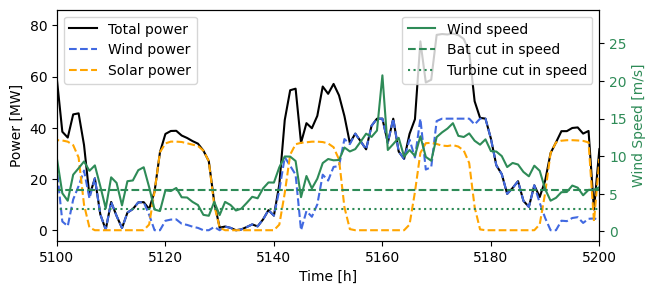

In [10]:
wind_power = [x/1000 for x in hybrid_plant.wind.generation_profile]
print(hybrid_plant.generation_profile)
total_gen = [x/1000 for x in hybrid_plant.grid.generation_profile]
solar_power = [x/1000 for x in hybrid_plant.pv.generation_profile]
wind_speeds = pd.read_csv('speed_dir_data.csv')
print(wind_speeds["14.205"])
plt.figure(figsize=[6,4])

fig, ax1 = plt.subplots(figsize=[7,3])
plt.plot(total_gen[1:], 'k', label="Total power")
ax1.plot(wind_power[1:], '--', color="royalblue", label="Wind power")
plt.plot(solar_power[1:], '--', color="orange", label="Solar power")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("Power [MW]", color='k')
# ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(5100, 5200)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
color='tab:seagreen'
ax2.set_ylabel("Wind Speed [m/s]", color='seagreen')
ax2.plot(wind_speeds["14.205"], '-', color='seagreen',label="Wind speed")
ax2.tick_params(axis='y', labelcolor='seagreen')
ax2.plot([4700,6900], [5.5, 5.5], '--', color='seagreen', label="Bat cut in speed")
ax2.plot([4700,6900], [3, 3], ':', color='seagreen', label="Turbine cut in speed")
ax2.legend()

schedule = hybrid_plant.site.curtailment_schedule
schedule_locs = []
for i in range(1,len(schedule)):
    if schedule[i]-schedule[i-1] != 0:
        print(schedule[i], schedule[i-1])
        if schedule[i] == 0:
            schedule_locs.append(i-1)
        else:
             schedule_locs.append(i)
           
print(schedule_locs[0:10])
plt.figure(figsize=[6,4])

fig, ax1 = plt.subplots(figsize=[7,4])
plt.plot(total_gen[1:], 'k', label="Total power")
ax1.plot(wind_power[1:], '--', color="royalblue", label="Wind power")
plt.plot(solar_power[1:], '--', color="orange", label="Solar power")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("Power [MW]", color='k')
# ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(5100, 5200)
ax1.legend(loc="upper left")
for i in range(0,len(schedule_locs)):
    if i%2 == 0:
        ax1.fill([schedule_locs[i]-1, schedule_locs[i]-1, schedule_locs[i+1]-1, schedule_locs[i+1]-1],[0, 80, 80, 0],color="lightsteelblue")

ax2 = ax1.twinx()
color='tab:seagreen'
ax2.set_ylabel("Wind Speed [m/s]", color='seagreen')
ax2.plot(wind_speeds["12.915"], '-', color='seagreen',label="Wind speed")
ax2.tick_params(axis='y', labelcolor='seagreen')
ax2.plot([4700,6900], [5, 5], '--', color='seagreen', label="Bat cut in speed")
ax2.plot([4700,6900], [3, 3], ':', color='seagreen', label="Turbine cut in speed")
ax2.legend()

# ax2.set_ylim([0,10])
# fig1 = plt.plot()
# plt.plot(wind_power[1:])
# plt.plot(solar_power[1:])
# plt.plot(total_gen[1:])
# plt.plot(wind_speeds)
# plt.plot([4700,6900], [5.5, 5.5], 'k--')
# plt.axis([5100,5150,-1,10])

